Imports

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Loading Datas into Dataframes

In [ ]:
XTrain = pd.read_csv('./XTrain.csv')
XTest = pd.read_csv('./XTest.csv')
YTrain = pd.read_csv('./YTrain.csv')
YTest = pd.read_csv('./YTest.csv')
XTrain = XTrain.values 
XTest  = XTest.values
YTrain = YTrain.values.reshape(-1, 1)
YTest  = YTest.values.reshape(-1, 1)

In [ ]:
XTrain.shape[1]

30

Creating classes for layers, activation functions, optimzers

In [ ]:
class Layer:
    def __init__(self, in_Features, out_Features):
        np.random.seed(42)
        self.W = np.random.randn(in_Features, out_Features) * np.sqrt(2.0 / in_Features)
        self.b = np.zeros(out_Features,)

        self.dw = None
        self.db = None
        self._X = None # just for caching purpose

    def forward(self, X):
        self._X = X
        return X@self.W + self.b

    def backward(self, dout):
        self.dw = self._X.T @ dout
        self.db = np.sum(dout, axis=0)
        return dout @ self.W.T


In [ ]:
class ReLU:
    def forward(self, X):
        self._mask = (X>0)
        return X * self._mask
    
    def backward(self, dout):
        return dout * self._mask # Turning off the gradients to zero where ReLU was not active

In [ ]:
class Sigmoid:
    def forward(self, X):
        X = np.array(X)
        self._out = 1/(1 + np.exp(-np.clip(X, -500, 500))) # preventing overflow for very large X
        return self._out
    
    def backward(self, dout):
        return dout * self._out * (1 - self._out)

Loss function - Binary Cross Entropy (logit loss)

In [ ]:
def bceLoss(YTrue, YPred):
    threshold = 1e-9
    YPred = np.clip(YPred, threshold, 1-threshold) # clipping to avoid log(0)
    return -np.mean(YTrue * np.log(YPred) + (1 - YTrue) * np.log(1 - YPred))

def bceGrad(YPred, YTrue):
    threshold = 1e-9
    YPred = np.clip(YPred, threshold, 1-threshold)
    return (-(YTrue/YPred) + ((1 - YTrue)/(1-YPred)))/len(YTrue)

Building the layers and network

In [ ]:
l1 = Layer(30, 32)# Input layer
relu = ReLU() # Activation function for input layer
l2 = Layer(32, 1) # Hidden layer
sigm = Sigmoid() # Activation function for Hidden layer

Forward & Backward passes

In [ ]:
def forward(X):
    z1 = l1.forward(X) # weighted sum of first layer
    a1 = relu.forward(z1) # Activation for first layer weighted sum - ReLU fxm
    z2 = l2.forward(a1) # weighted sum of hidden layer
    out = sigm.forward(z2) # Activation for hidden layer weighted sum - SIGMOID fxn

    return out

def backward(dout):
    dout = sigm.backward(dout)
    dout = l2.backward(dout)
    dout = relu.backward(dout)
    dout = l1.backward(dout)



Training Loop

In [ ]:
# --------------- hyperparameters -----------------------------------------
learnignRate = 0.01
epochs = 500
batchSize = 32
N = len(XTrain)
# -------------------------------------------------------------------------

# Logging training history, with each epoch's loss | training accuracy | validation set accuracy
history = {
            'trainLoss' : [],
            'trainAcc': [],
            'valAcc' : []
        }

for epoch in range(epochs):
    
    # shuffling each batch
    idx = np.random.permutation(N).tolist()
    XShuffled, YShuffled = XTrain[idx], YTrain[idx]

    epochLoss, nBatches = 0, 0
    
    for i in range(0, N, batchSize):
        XBatch = XShuffled[i : i + batchSize]
        YBatch = YShuffled[i : i + batchSize]


        out = forward(XBatch)

        loss = bceLoss(YBatch, out)
        epochLoss += loss
        nBatches += 1
        # We are keep tracking of values epochLoss and nBatches, so that at last we can take average of loss :- (sum of loss in each batch for one epoch)/(no of batches)

        gradient = bceGrad(out, YBatch)

        backward(gradient)

        l1.W = l1.W - (learnignRate * l1.dw)
        l1.b = l1.b - (learnignRate * l1.db)
        l2.W = l2.W - (learnignRate * l2.dw)
        l2.b = l2.b - (learnignRate * l2.db)
    # ------------------------Each Epoch metrics ------------------------------------
    avgLoss = epochLoss/nBatches
    trainPred = ( forward(XTrain) >= 0.5 ).astype(int).flatten()
    valPred = ( forward(XTest) >= 0.5 ).astype(int).flatten()
    trainingAccurary = np.mean(trainPred == YTrain.flatten())
    validationAccurary = np.mean(valPred == YTest.flatten())

    history['trainLoss'].append(avgLoss)
    history['trainAcc'].append(trainingAccurary)
    history['valAcc'].append(validationAccurary)

    if epoch%50 == 0 or epoch == N-1:
        print(f"Epoch-{epoch} | loss : {avgLoss} | Training Accuracy : {trainingAccurary*100:.1f}% | Validation Accuracy : {validationAccurary*100:.1f}%")

print("Training Completed.....")


Epoch-0 | loss : 0.03069173868988167 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-50 | loss : 0.02892591036090009 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-100 | loss : 0.03305073074093515 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-150 | loss : 0.024562498958046422 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-200 | loss : 0.023691098401595282 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-250 | loss : 0.0217055320154405 | Training Accuracy : 99.3% | Validation Accuracy : 97.4%
Epoch-300 | loss : 0.021469493199648984 | Training Accuracy : 99.6% | Validation Accuracy : 97.4%
Epoch-350 | loss : 0.018776311841571205 | Training Accuracy : 99.6% | Validation Accuracy : 97.4%
Epoch-400 | loss : 0.018070135032681043 | Training Accuracy : 99.6% | Validation Accuracy : 97.4%
Epoch-450 | loss : 0.018316062933825657 | Training Accuracy : 99.6% | Validation Accuracy : 97.4%
Epoch-454 | loss : 0.0168005

Model Evaluation

In [ ]:
testPred = (forward(XTest)>=0.5).astype(int).flatten()
testAcc = np.mean( testPred == YTest.flatten())

# CONFUSION MATRIX
TruePos = np.sum((testPred == 1) & (YTest == 1))
TrueNeg = np.sum((testPred == 0) & (YTest == 0))
FalsePos = np.sum((testPred == 1) & (YTest == 0))
FalseNeg = np.sum((testPred == 0) & (YTest == 1))

# metrics
precision = TruePos / (TruePos + FalsePos)
recall = TruePos / (TruePos + FalseNeg)
f1 = 2 * precision * recall / (precision + recall)

print(f"Test Accuracy: {testAcc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 score: {f1}\n")
print("Confusion matrix")
print("Predicted :   0     1")
print(f"Actual 0 :  {TrueNeg:>3}   {FalsePos:>3}")
print(f"Actual 1 :  {TruePos:>3}   {FalsePos:>3}")

Test Accuracy: 0.9736842105263158
Precision: 0.37719298245614036
Recall: 0.3684210526315789
F1 score: 0.37275541795665634

Confusion matrix
Predicted :   0     1
Actual 0 :  5112   2982
Actual 1 :  1806   2982


Training Curve

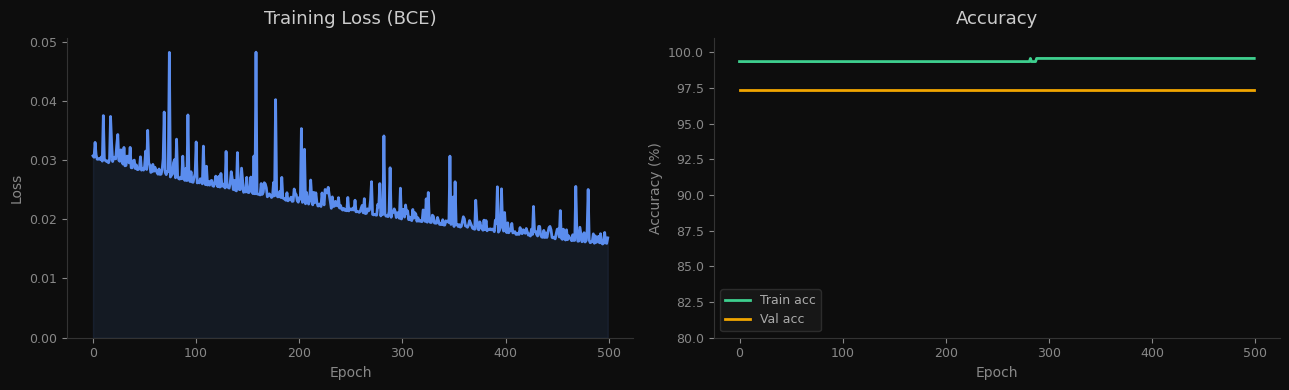

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d0d0d')
epochs_range = range(len(history["trainLoss"]))

for ax in axes:
    ax.set_facecolor('#0d0d0d')
    for sp in ['bottom','left']:   ax.spines[sp].set_color('#333')
    for sp in ['top','right']:     ax.spines[sp].set_visible(False)
    ax.tick_params(colors='#888', labelsize=9)
    ax.yaxis.label.set_color('#888')
    ax.xaxis.label.set_color('#888')
    ax.title.set_color('#ccc')

# Loss
axes[0].plot(epochs_range, history["trainLoss"], color='#5b8dee', linewidth=2)
axes[0].fill_between(epochs_range, history["trainLoss"], alpha=0.1, color='#5b8dee')
axes[0].set_title('Training Loss (BCE)', fontsize=13, pad=10)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_ylim(bottom=0)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history["trainAcc"]], color='#3ecf8e', linewidth=2, label='Train acc')
axes[1].plot(epochs_range, [a*100 for a in history["valAcc"]],   color='#f0a500', linewidth=2, label='Val acc')
axes[1].set_title('Accuracy', fontsize=13, pad=10)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(80, 101)
axes[1].legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333', labelcolor='#aaa')

plt.tight_layout()
# plt.savefig('training_curves.png', dpi=130, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
# print("Plot saved as training_curves.png")

Predicting on a new sample

In [ ]:
def predict(sample):
    prediction = int((forward(sample) >= 0.5)[0])
    predictedClass = "Benign" if prediction == 0 else "Malignant"
    return predictedClass

Exporting results file based on samples of test data

In [ ]:
pd.DataFrame(testPred).astype(str).replace({"0": "Benign", "1": "Malignant"}).to_csv('./Results.csv')

Inspecting Learned Weights

In [ ]:
print("Learned weight shapes (always same as initialized):")
print(f"  l1.W : {l1.W.shape}   (30 inputs  → 32 hidden neurons)")
print(f"  l1.b : {l1.b.shape}         (one bias per hidden neuron)")
print(f"  l2.W : {l2.W.shape}    (32 hidden → 1 output neuron)")
print(f"  l2.b : {l2.b.shape}           (one bias for output)")
print()
print("Gradient shapes (always match their parameter):")
print(f"  l1.dW: {l1.dw.shape}  ← same as l1.W")
print(f"  l2.dW: {l2.dw.shape}   ← same as l2.W")

Learned weight shapes (always same as initialized):
  l1.W : (30, 32)   (30 inputs  → 32 hidden neurons)
  l1.b : (32,)         (one bias per hidden neuron)
  l2.W : (32, 1)    (32 hidden → 1 output neuron)
  l2.b : (1,)           (one bias for output)

Gradient shapes (always match their parameter):
  l1.dW: (30, 32)  ← same as l1.W
  l2.dW: (32, 1)   ← same as l2.W
